# 03 - plot_hex_temperature()

This notebook __was used to create function plot_hex_temperature()__ function.

## __Import libraries__

In [1]:
from pathlib import Path

current_path = Path().resolve()

for parent in current_path.parents:
    if parent.name == "odc":
        project_root = parent
        break

print(project_root)

/home/jovyan/odc


In [2]:
import os
import sys

import pandas as pd
import geopandas as gpd
import numpy as np

import matplotlib.pyplot as plt
# Import logo image
import matplotlib.image as mpimg
# Place logo image above plot
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
# Wrap title text inside plots
from textwrap import wrap

# Import cm, colors and colorbar to create colormap legends manually
import matplotlib.cm as cm
import matplotlib.colors as colors #Tendency for only red or only green values
from matplotlib.colors import TwoSlopeNorm #Tendency colorbar red to green
import matplotlib.colorbar as colorbar

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

module_path = os.path.abspath(os.path.join(project_root))
if module_path not in sys.path:
    sys.path.append(module_path)
    print("Path found")
    import odc

Path found


## __Config notebook__

In [3]:
res = 8
city = 'Monterrey'

## __Load data__

In [4]:
# Load data test
data_schema = 'raster_analysis'
data_table = 'temperature_analysis_hex'
# Load city's hexs filtering for urban areas if required
query = f"SELECT * FROM {data_schema}.{data_table} WHERE \"city\" = '{city}\' AND \"res\" = '{res}\'"
data_gdf = odc.gdf_from_query(query, geometry_col='geometry')

# Show
print(data_gdf.crs)
print(data_gdf.shape)
data_gdf.head(2)

epsg:4326
(2177, 17)


,hex_id,geometry,res,temperature_mean,temperature_std,temperature_median,temperature_max,temperature_min,temperature_diff,temperature_tend,temperature_2018,temperature_2019,temperature_2020,temperature_2021,temperature_2022,temperature_2023,city
0,8848a20003fffff,"POLYGON ((-100.22452 25.62452, -100.21977 25.6...",8,25.740937,5.016255,26.780310,31.633325,16.752304,14.881022,0.088190,24.597139,25.335839,25.745514,25.590871,24.272120,28.055165,Monterrey
1,8848a20005fffff,"POLYGON ((-100.20900 25.61768, -100.20426 25.6...",8,24.327934,5.970338,24.690935,31.563002,13.973481,17.589521,0.062637,24.518901,24.520371,24.520010,23.556975,21.596834,27.384884,Monterrey


In [5]:
# Download area of interest (aoi)
print('--- Downloading area of interest.')
metro_schema = 'metropolis'
metro_table = 'metro_gdf_2020'
query = f"SELECT * FROM {metro_schema}.{metro_table} WHERE \"city\" LIKE \'{city}\'"
mun_gdf = odc.gdf_from_query(query, geometry_col='geometry')

# Create area of interest from dissolved municipalities
mun_gdf.to_crs("EPSG:6372",inplace=True)
aoi = mun_gdf.buffer(5)
aoi_gdf = gpd.GeoDataFrame(geometry=aoi,crs="EPSG:6372").dissolve()
aoi_gdf.to_crs("EPSG:4326",inplace=True)

# Download Network (G, nodes, edges)
print('--- Downloading network.')
network_schema = 'osmnx'
nodes_table = 'nodes_osmnx_23_point'
edges_table = 'edges_speed_23_line'
G, nodes_gdf, edges_gdf = odc.graph_from_hippo(aoi, schema=network_schema, edges_folder=edges_table, nodes_folder=nodes_table)

# Show
print(edges_gdf.crs)
print(edges_gdf.shape)
edges_gdf.head(2)

--- Downloading area of interest.
--- Downloading network.
EPSG:4326
(570458, 19)


osmid  oneway  \
u          v          key                                              
5426555224 5429211221 0    [563021416, 232005948, 563557525]   False   
           7611208289 0                            814840924   False   

                                                                    name  \
u          v          key                                                  
5426555224 5429211221 0    Carretera Villa de García-Icamole-La Azufrosa   
           7611208289 0                                             None   

                               highway   length  \
u          v          key                         
5426555224 5429211221 0      secondary  770.965   
           7611208289 0    residential    9.983   

                                                                    geometry  \
u          v          key                                                      
5426555224 5429211221 0    LINESTRING (-100.80683 25.91813, -100.80694 25...   
           7611208289 0    LINESTRING (-100.80683 25.91813, -100.80682 25...   

                           grade  grade_abs lanes bridge maxspeed     ref  \
u          v          key                                                   
5426555224 5429211221 0   -0.008      0.008  None    yes       80  NL 129   
           7611208289 0    0.000      0.000  None   None     None    None   

                          access junction service tunnel width  walkspeed  \
u          v          key                                                   
5426555224 5429211221 0     None     None    None   None  None   3.889553   
           7611208289 0     None     None    None   None  None   4.000000   

                            time_min  
u          v          key             
5426555224 5429211221 0    11.892856  
           7611208289 0     0.149745

## __Function development__

## __Function testing__

### __Function testing__ - Function with temperature anomaly (temperature_mean vs overall mean) and temperature tendency

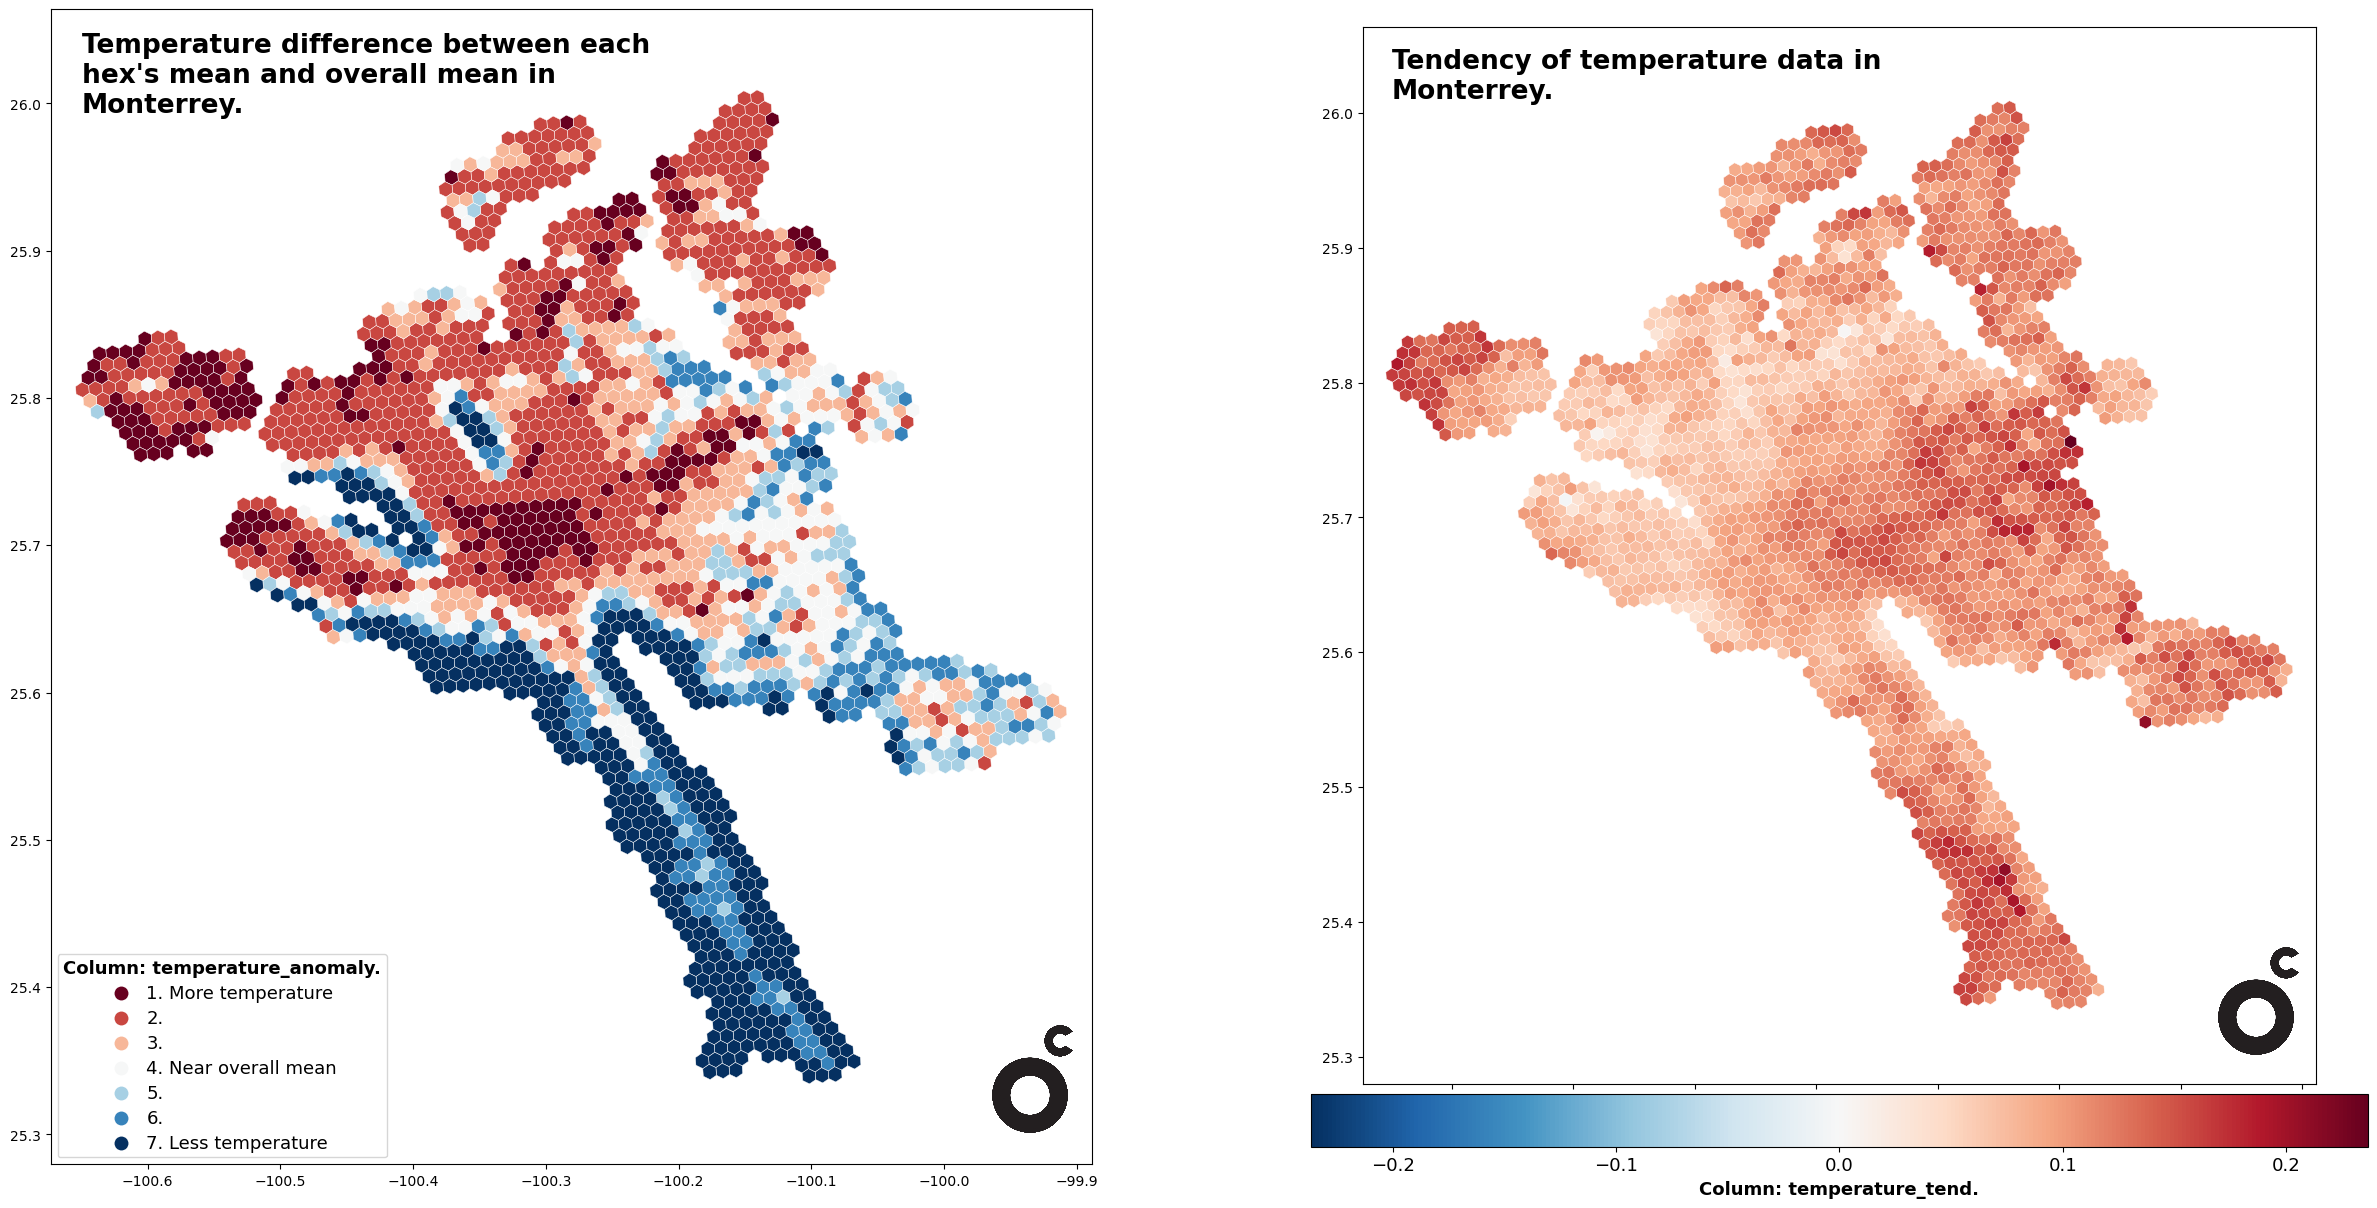

In [6]:
fig,axs = plt.subplots(1,2,figsize=(30,15))

# ----- TEMPERATURE ANOMALY (temperature_mean vs overall mean) -----
# Regular temperature_anomaly plot
# (Passing any string other than 'temperature_tend' also plots anomaly)
odc.plot_hex_temperature(data_gdf = data_gdf,
                         location_name = city,
                         ax=axs[0],
                        )

# ----- TEMPERATURE TENDENCY 2018-2023 -----
# temperature_tend plot
odc.plot_hex_temperature(data_gdf = data_gdf,
                         column = 'temperature_tend',
                         location_name = city,
                         ax=axs[1],
                        )